In [1]:
import joblib
import pandas as pd

In [2]:
xgb_model = joblib.load("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/models/xgb_credit_model_final.pkl")

In [3]:
ytst = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/y_test_beforeenc.csv")

In [4]:
import pandas as pd

test_df = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/X_test_beforeenc.csv")
print(test_df.shape)
test_df.head()

(272380, 99)


,Unnamed: 0,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,home_ownership,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,emp_length_int,region,l_condition_Good Loan
0,1059430,12000.0,12000.0,12000.0,36 months,10.75,391.45,B,B4,OWN,...,40300.0,14926.0,32800.0,0.0,N,Cash,N,5.0,West,True
1,114475,9500.0,9500.0,9500.0,36 months,9.99,306.50,B,B3,RENT,...,70144.0,47508.0,13200.0,56944.0,N,Cash,N,5.0,West,True
2,1293736,2500.0,2500.0,2500.0,36 months,15.31,87.05,C,C4,RENT,...,21900.0,19615.0,11700.0,10200.0,N,Cash,N,7.0,SouthEast,True
3,1773783,29700.0,29700.0,29700.0,36 months,16.20,1047.10,C,C4,RENT,...,222286.0,44722.0,36300.0,6936.0,N,Cash,N,8.0,West,True
4,1822325,20775.0,20775.0,20775.0,60 months,23.50,591.65,F,F1,MORTGAGE,...,252420.0,53447.0,1000.0,69621.0,N,Cash,N,8.0,SouthWest,True


In [5]:
standardized_test_X = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/X_test_final.csv")

In [6]:
y_pred_proba = xgb_model.predict_proba(standardized_test_X)[:, 1]
y_pred_proba

array([0.26170936, 0.07812294, 0.05750654, ..., 0.16856886, 0.89307976,
       0.91800153], dtype=float32)

In [7]:
test_df_unscaled = test_df.copy()
test_df_unscaled["predicted_PD"] = y_pred_proba

 Expected Loss Formula:
 
![alt text](images.png)


In [8]:
# Make sure these exist
assert 'funded_amnt' in test_df_unscaled.columns, "funded_amnt not found"
assert len(y_pred_proba) == len(test_df_unscaled), "Mismatch in prediction and test set size"

# Define LGD values
LGD_values = [0.45, 0.65, 0.80]

# For each LGD, compute Expected Loss
for lgd in LGD_values:
    test_df_unscaled[f'expected_loss_lgd_{int(lgd*100)}'] = y_pred_proba * lgd * test_df_unscaled['funded_amnt']

# Optional: view first few rows
print(test_df_unscaled[[f'expected_loss_lgd_{int(lgd*100)}' for lgd in LGD_values]].head())


   expected_loss_lgd_45  expected_loss_lgd_65  expected_loss_lgd_80
0           1413.230538           2041.332901           2512.409985
1            333.975527            482.409099            593.734322
2             64.694849             93.448116            115.013076
3           3735.531941           5395.768359           6640.945673
4           7534.510204          10883.181131          13394.684945


In [9]:
test_df_unscaled[[f'expected_loss_lgd_{int(lgd*100)}' for lgd in LGD_values]]

,expected_loss_lgd_45,expected_loss_lgd_65,expected_loss_lgd_80
0,1413.230538,2041.332901,2512.409985
1,333.975527,482.409099,593.734322
2,64.694849,93.448116,115.013076
3,3735.531941,5395.768359,6640.945673
4,7534.510204,10883.181131,13394.684945
...,...,...,...
272375,708.281354,1023.073053,1259.166924
272376,835.344553,1206.608725,1485.057020
272377,1061.983794,1533.976614,1887.971282
272378,14066.005349,20317.562819,25006.234050


#### Expected Loss Columns Explanation

- The table shows expected monetary losses for individual loans under different **Loss Given Default (LGD)** scenarios:
  - `expected_loss_lgd_45` → Assumes 45% of the loan amount is lost if the borrower defaults.
  - `expected_loss_lgd_65` → Assumes 65% is lost.
  - `expected_loss_lgd_80` → Assumes 80% is lost.

- The formula used to calculate expected loss per loan is:
  - `Expected Loss = PD × LGD × Loan Amount`

- Each row represents one loan in the test set.
- Values are in **dollars** and represent the **expected financial loss** associated with that loan, based on its predicted probability of default.

- Higher PDs or larger loan amounts naturally lead to higher expected losses.
- These values are crucial for:
  - Pricing decisions,
  - Portfolio risk estimation,
  - Capital allocation under Basel guidelines.


### EL Calculation done.

---

## Risk free interest rate calculation

#### Risk-Free Rate Estimation (r₀)

- The **baseline interest rate (r₀)** is estimated using loans assigned **Grade A**, which are considered the lowest-risk borrowers.
- We compute the **average interest rate** for these Grade A loans:  
  `low_risk_rates = mean(int_rate | grade == 'A')`
- To approximate a **risk-free or minimal-risk return**, we apply a conservative **discount factor of 80%**:  
  `r₀ = 0.8 × average_rate_for_Grade_A`
- This adjusted rate reflects a realistic floor rate in Lending Club's portfolio and is used in the pricing formula:  
  `Interest Rate = r₀ + α × PD`


In [10]:
low_risk_rates = test_df_unscaled[test_df_unscaled['grade'] == 'A']['int_rate'].mean()
r0 = low_risk_rates * 0.8
r0

5.694068822679123

---

## Risk Based Pricing Formula:

## ri = r0 + α⋅PDi

### Risk-Based Loan Pricing Simulation

#### - Objective:
To simulate how profits change under a **risk-based pricing strategy**, where the interest rate varies based on predicted default probability (PD).



#### Step 1: Generate Interest Rates per Alpha
- For each risk-aversion factor **α ∈ {0.5, 1.0, 1.5, 2.0, 3.0}**, interest rates were calculated using the formula:  
  `Interest Rate = r₀ + α × PD`
- This results in columns like `interest_rate_alpha_0.5`, ..., for each loan, capturing the personalized rate based on its risk.



#### Step 2: Compute Profits for All Loans
- For each combination of **LGD (Loss Given Default)** and **Alpha**:
  - **Revenue** = `Interest Rate × Loan Amount`
  - **Expected Loss** = `PD × LGD × Loan Amount`
  - **Profit** = `Revenue - Expected Loss`
- These are summed across all loans to get total expected profit for that (α, LGD) pair.



#### Step 3: Threshold-Based Approval (Optional Constraint)
- Loans with predicted PD < 0.55 are **approved**; the rest are rejected.
- Profits are recalculated only on the **approved subset** to simulate real-world lending policies.



#### Output:
- A **Profit Matrix** is created showing total expected profits for each **(α, LGD)** combination.
- This helps visualize how profit is impacted by different levels of risk aversion and assumed LGD values.



#### Insight:
- Higher α increases interest rates, boosting revenue but potentially reducing approval and increasing borrower burden.
- Balancing α and LGD allows lenders to **optimize profitability** while managing portfolio risk.


In [11]:
alpha_list = [0.5, 1.0, 1.5, 2.0, 3.0]

In [12]:
# Add interest rate columns for each alpha
for alpha in alpha_list:
    test_df_unscaled[f'interest_rate_alpha_{alpha}'] = r0 + alpha * y_pred_proba

# View first few results
cols_to_show = [f'interest_rate_alpha_{alpha}' for alpha in alpha_list]


In [13]:
interest_rate_df = test_df_unscaled[cols_to_show].head()

In [14]:
test_df_unscaled

,Unnamed: 0,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,home_ownership,...,l_condition_Good Loan,predicted_PD,expected_loss_lgd_45,expected_loss_lgd_65,expected_loss_lgd_80,interest_rate_alpha_0.5,interest_rate_alpha_1.0,interest_rate_alpha_1.5,interest_rate_alpha_2.0,interest_rate_alpha_3.0
0,1059430,12000.0,12000.0,12000.0,36 months,10.75,391.45,B,B4,OWN,...,True,0.261709,1413.230538,2041.332901,2512.409985,5.824924,5.955778,6.086633,6.217488,6.479197
1,114475,9500.0,9500.0,9500.0,36 months,9.99,306.50,B,B3,RENT,...,True,0.078123,333.975527,482.409099,593.734322,5.733130,5.772192,5.811254,5.850315,5.928438
2,1293736,2500.0,2500.0,2500.0,36 months,15.31,87.05,C,C4,RENT,...,True,0.057507,64.694849,93.448116,115.013076,5.722822,5.751575,5.780329,5.809082,5.866589
3,1773783,29700.0,29700.0,29700.0,36 months,16.20,1047.10,C,C4,RENT,...,True,0.279501,3735.531941,5395.768359,6640.945673,5.833819,5.973570,6.113320,6.253071,6.532572
4,1822325,20775.0,20775.0,20775.0,60 months,23.50,591.65,F,F1,MORTGAGE,...,True,0.805938,7534.510204,10883.181131,13394.684945,6.097038,6.500007,6.902976,7.305944,8.111882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272375,1278084,34875.0,34875.0,34775.0,60 months,20.20,927.86,E,E3,RENT,...,True,0.045131,708.281354,1023.073053,1259.166924,5.716635,5.739200,5.761766,5.784332,5.829463
272376,1079111,22400.0,22400.0,22400.0,36 months,7.89,700.80,A,A5,RENT,...,True,0.082871,835.344553,1206.608725,1485.057020,5.735505,5.776940,5.818376,5.859812,5.942683
272377,241333,14000.0,14000.0,14000.0,60 months,7.89,283.14,A,A5,MORTGAGE,...,True,0.168569,1061.983794,1533.976614,1887.971282,5.778353,5.862638,5.946922,6.031207,6.199776
272378,206377,35000.0,35000.0,34925.0,60 months,17.86,886.11,D,D5,MORTGAGE,...,False,0.893080,14066.005349,20317.562819,25006.234050,6.140609,6.587149,7.033689,7.480228,8.373308


In [15]:
import pandas as pd
import numpy as np

lgds = [0.45, 0.65, 0.80]
alphas = [0.5, 1.0, 1.5, 2.0, 3.0]

# Assume these are already available:
# test_df['funded_amnt']
# y_pred_proba: Series or np.array of PDs
# test_df[f'interest_rate_alpha_{α}'] for each α

profit_results = {}  # Stores profit summaries per LGD

for lgd in lgds:
    profit_per_alpha = {}
    for alpha in alphas:
        col_name = f"interest_rate_alpha_{alpha}"
        
        # Revenue = interest_rate * loan amount
        revenue = test_df_unscaled[col_name] / 100 * test_df_unscaled['funded_amnt']
        
        # Expected Loss = PD * LGD * loan amount
        expected_loss = y_pred_proba * lgd * test_df_unscaled['funded_amnt']
        
        # Profit = Revenue - Expected Loss
        profit = revenue - expected_loss
        
        # Total profit for this LGD and alpha
        total_profit = profit.sum()
        
        profit_per_alpha[alpha] = round(total_profit, 2)
    
    profit_results[lgd] = profit_per_alpha


In [16]:
# Make sure this is your raw test set before scaling
loan_amounts = test_df_unscaled['funded_amnt'].values


In [17]:
threshold = 0.550
approved_mask = y_pred_proba < threshold

approved_pd = y_pred_proba[approved_mask]
approved_ead = loan_amounts[approved_mask]  # assuming this is funded_amnt

In [22]:
lgd_values = [0.45,0.65, 0.8]
alpha_values = [0.5, 1.0, 1.5, 2.0, 3.0]
base_rate = 5.6941 / 100

profit_matrix = pd.DataFrame(index=alpha_values, columns=lgd_values)

for lgd in lgd_values:
    for alpha in alpha_values:
        # Interest Rate per loan
        max_rate = 0.36  # 36% annual max, or adjust
        interest_rates = np.minimum(base_rate + alpha * approved_pd, max_rate)
        # interest_rates = base_rate + alpha * approved_pd

        # Expected Revenue = interest × EAD
        expected_revenue = interest_rates * approved_ead

        # Expected Loss = PD × LGD × EAD
        expected_loss = approved_pd * lgd * approved_ead

        # Profit = Revenue - Expected Loss
        profit = expected_revenue - expected_loss

        # Total Profit
        total_profit = profit.sum()
        profit_matrix.loc[alpha, lgd] = total_profit


In [23]:
print("=== PROFIT AFTER REJECTION (PD < 0.55) ===")
profit_matrix

=== PROFIT AFTER REJECTION (PD < 0.55) ===


,0.45,0.65,0.80
0.5,171552338.420712,109050957.073708,62174906.366767
1.0,295406956.427748,232905575.080744,186029524.373803
1.5,375639434.744469,313138053.397465,266262002.690524
2.0,435260349.860585,372758968.513581,325882917.80664
3.0,520760564.344219,458259182.997215,411383132.290274


### Profit Matrix from Risk-Based Pricing Strategy

#### - Description:
This table shows the **total expected profit** (in $) under different **risk-aversion levels (α)** and **Loss Given Default (LGD)** values. Each row represents a specific alpha (α), and each column represents an LGD assumption.

#### - Parameters Used:
- **α (Alpha)**: Multiplier applied to predicted probability of default (PD) to increase interest rates.
- **LGD**: Assumed loss percentage if the borrower defaults.
- **Threshold**: Only loans with PD < 0.55 were approved.

#### - Interpretation:

| α (Risk Premium) | Profit @ LGD=0.45 | Profit @ LGD=0.65 | Profit @ LGD=0.80 |
|------------------|-------------------|-------------------|-------------------|
| 0.5              | $171.6M           | $109.1M           | $62.2M            |
| 1.0              | $295.4M           | $232.9M           | $186.0M           |
| 1.5              | $375.6M           | $313.1M           | $266.3M           |
| 2.0              | $435.3M           | $372.8M           | $325.9M           |
| 3.0              | $520.8M           | $458.3M           | $411.4M           |

#### - Key Takeaways:
- Increasing **α** still improves profit, as higher-risk borrowers are charged more.
- Profitability decreases as **LGD** increases, due to larger losses when defaults occur.
- Compared to the earlier version, gains from increasing α are more modest, suggesting **diminishing returns** at higher risk levels.
- This matrix supports choosing an **α between 1.5–2.0** under realistic LGD assumptions (e.g., 0.65–0.80) for a **balanced risk-return** profile.



In [24]:
import sys
sys.path.append("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/Scripts")

from pricing_strategy_analysis import run_pricing_analysis

### Risk-Based Pricing Strategy Visualization

#### - Purpose:
This function visualizes the **profitability and pricing strategy** under different combinations of:
- **LGD (Loss Given Default)** assumptions  
- **α (Alpha)** values, which control the risk premium added to interest rates  
- **Threshold-only strategy** vs **Risk-Based Pricing** strategy comparisons



#### - Visualizations Generated:

1. **Profit vs Alpha for Different LGDs**  
   - Shows how total profit increases as α increases, for each LGD level.
   - Helps determine the optimal α based on the assumed LGD.

2. **Average Interest Rate vs Alpha**  
   - Plots the average interest rate charged across customers for each α.
   - Demonstrates how pricing becomes more aggressive with higher α.

3. **Step 3 vs Risk-Based Pricing Profits**  
   - Compares profit from best threshold-only strategy (e.g., threshold = 0.65)  
     against a selected risk-based pricing setup (e.g., α = 2.0, LGD = 0.45).

4. **Profit vs Alpha at Different Thresholds**  
   - Compares profitability curves for thresholds like 0.65, 0.75, 0.80.
   - Helps visualize how combining pricing and thresholding affects profits.

5. **Risk-Return Frontier (Optional Plot)**  
   - Scatter plot of average return (interest rate) vs LGD (risk).
   - Bubble size represents total profit.
   - Visual tool to understand trade-offs between profitability and credit risk.



#### - Key Insights:
- Profit increases with higher α as riskier customers are charged more.
- Risk-based pricing can outperform static thresholding alone.
- Higher LGDs reduce profitability, emphasizing the importance of accurate LGD estimation.
- Visual comparisons help choose a risk-return balance aligned with business goals.


In [25]:
expected_df = pd.read_csv("expected_prof_df.csv")
thresholds = np.round(np.arange(0.30, 0.85, 0.05), 2)

step3_profits = {}
for t in thresholds:
    row = expected_df[np.isclose(expected_df['threshold'], t, atol=1e-4)]
    if not row.empty:
        step3_profits[float(t)] = row['net_benefit'].values[0]
    else:
        print(f"Threshold {t:.2f} not found!")

# Display
print("\nStep 3 Profits (Threshold-only Strategy):")
for t, profit in step3_profits.items():
    print(f"Threshold {t:.2f}: ${profit:,.0f}")



Step 3 Profits (Threshold-only Strategy):
Threshold 0.30: $617,382,673
Threshold 0.35: $629,779,389
Threshold 0.40: $638,637,408
Threshold 0.45: $644,946,343
Threshold 0.50: $649,081,953
Threshold 0.55: $651,123,056
Threshold 0.60: $650,253,400
Threshold 0.65: $646,301,950
Threshold 0.70: $638,504,445
Threshold 0.75: $624,434,001
Threshold 0.80: $601,751,098


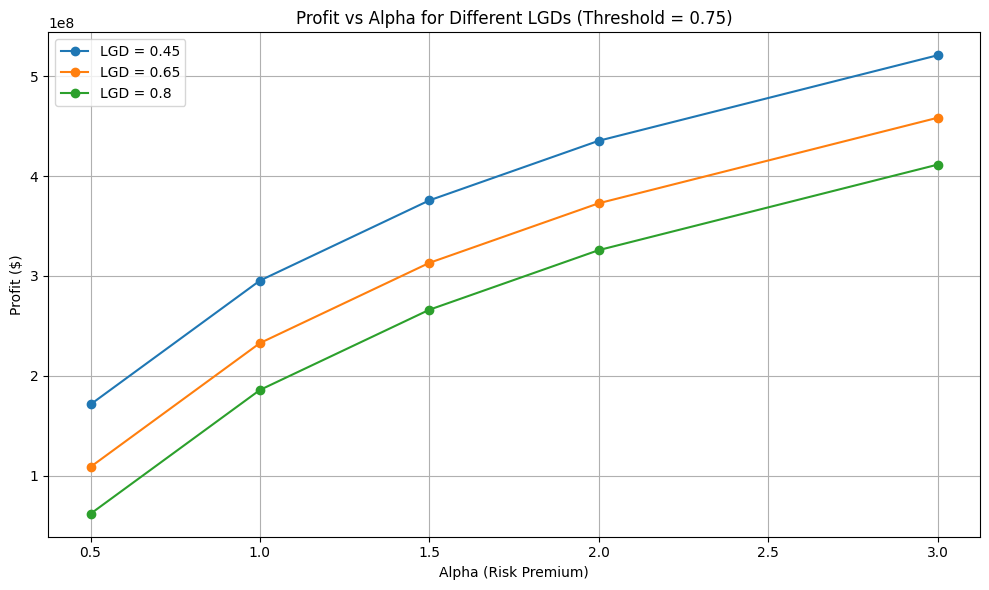

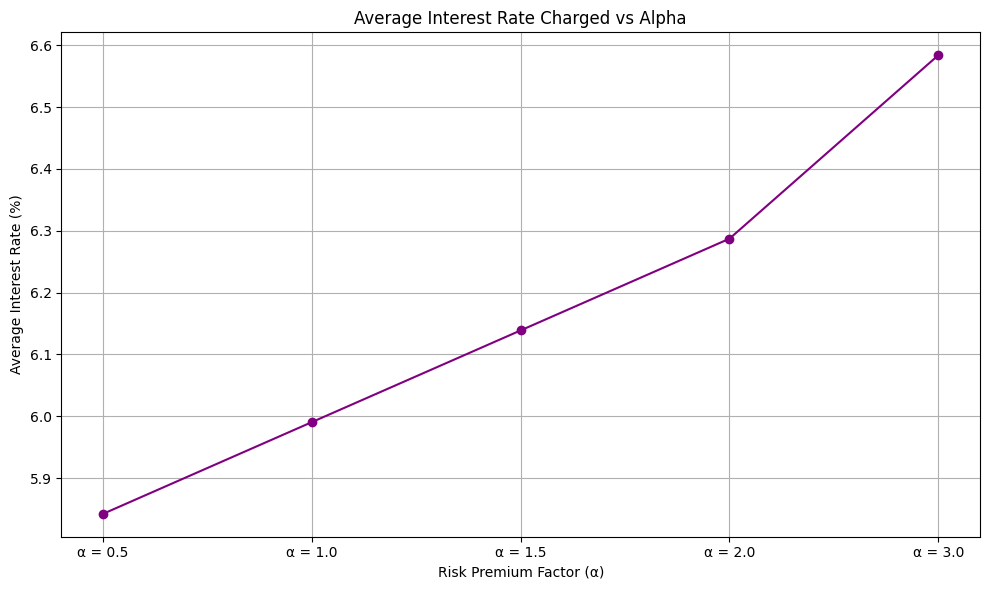

C:\Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/Scripts\pricing_strategy_analysis.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Strategy', y='Profit ($)', palette='Set2')


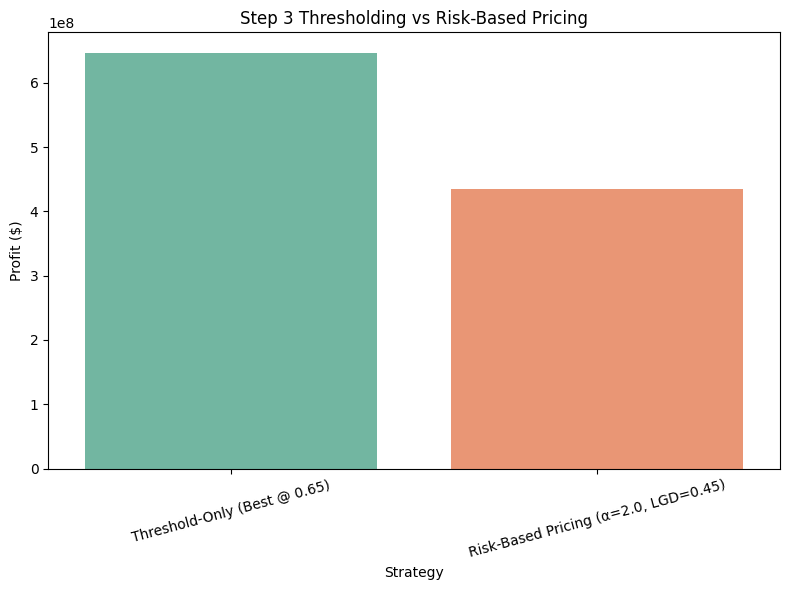

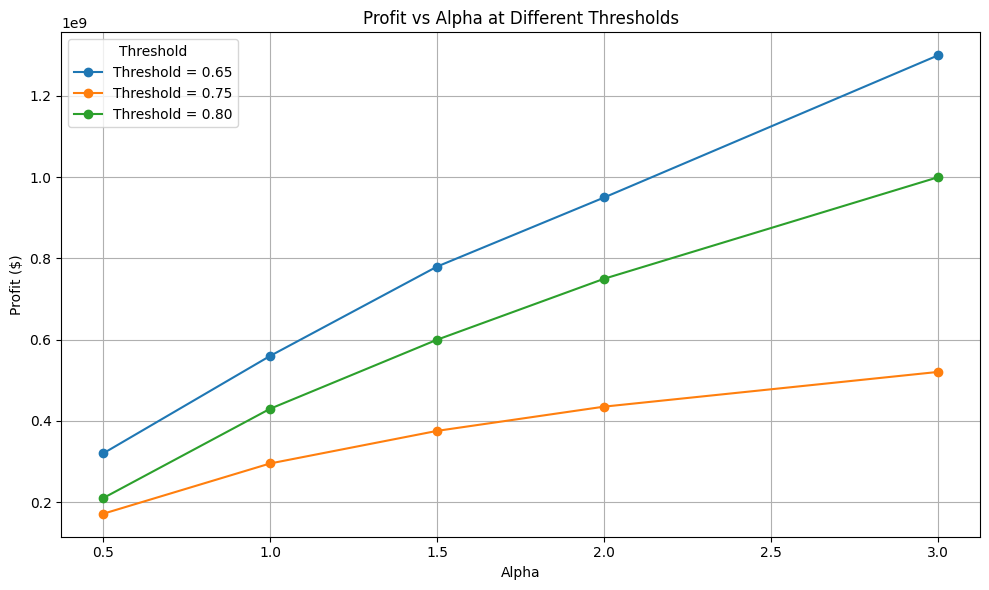

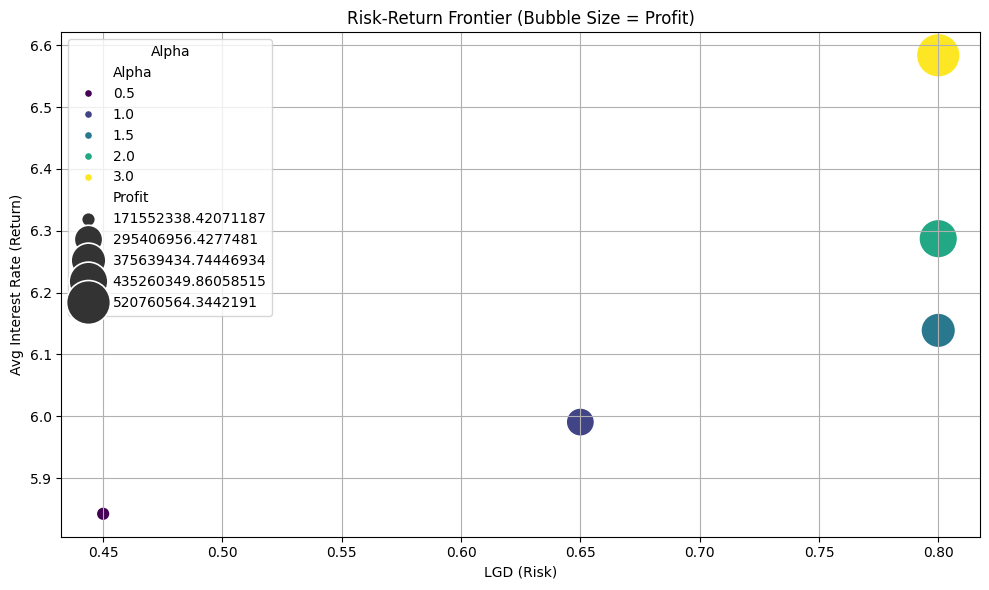

In [26]:
from pricing_strategy_analysis import run_pricing_analysis

run_pricing_analysis(profit_matrix, interest_rate_df, step3_profits)

In [27]:
test_df_unscaled.to_csv("df_for_simulation.csv")

In [28]:
profit_matrix.to_csv("profit_0_55.csv")

---

## Bank style rates

In [111]:
import pandas as pd
import numpy as np

# === Inputs ===
LGD = 0.65  # Bank LGD assumption for unsecured loans
r0 = 0.04   # Base cost of funds (4%)
alpha_list = [0.5, 1.0, 1.5]  # Risk premiums
bank_thresholds = [0.03, 0.05, 0.08, 0.10, 0.15]  # Conservative approval thresholds
cost_per_loan = 500  # Operational cost per loan

# === Arrays ===
pd_array = y_pred_proba  # predicted PDs
y_array = ytst['target'].values  # true default flags
ead_array = test_df_unscaled['funded_amnt'].values  # Exposure at default (loan amount)

# === Simulation ===
bank_results = []

for alpha in alpha_list:
    for threshold in bank_thresholds:
        approved_mask = pd_array < threshold
        if approved_mask.sum() == 0:
            continue  # skip if no approvals

        pd_approved = pd_array[approved_mask]
        y_approved = y_array[approved_mask]
        ead_approved = ead_array[approved_mask]

        # Risk-based pricing
        rates = r0 + alpha * pd_approved

        # Expected metrics
        expected_loss = pd_approved * LGD * ead_approved
        expected_revenue = rates * ead_approved
        expected_profit = expected_revenue - expected_loss - cost_per_loan
        portfolio_profit = expected_profit.sum()

        # Realized metrics
        realized_loss = (y_approved * LGD * ead_approved).sum()
        realized_revenue = ((1 - y_approved) * rates * ead_approved).sum()
        realized_profit = realized_revenue - realized_loss - (cost_per_loan * len(pd_approved))

        bank_results.append({
            'alpha': alpha,
            'threshold': threshold,
            'approval_rate': approved_mask.mean(),
            'avg_pd': pd_approved.mean(),
            'avg_rate': rates.mean(),
            'avg_profit_per_loan': expected_profit.mean(),
            'portfolio_expected_profit': portfolio_profit,
            'realized_profit': realized_profit,
            'approved_loans': approved_mask.sum()
        })

bank_results_df = pd.DataFrame(bank_results)
bank_results_df.sort_values(by='portfolio_expected_profit', ascending=False).reset_index(drop=True)

,alpha,threshold,approval_rate,avg_pd,avg_rate,avg_profit_per_loan,portfolio_expected_profit,realized_profit,approved_loans
0,1.5,0.15,0.537264,0.051520,0.117280,660.940534,9.672204e+07,1.370010e+08,146340
1,1.5,0.10,0.462259,0.039969,0.099953,525.251843,6.613446e+07,9.377295e+07,125910
2,1.5,0.08,0.416466,0.034522,0.091784,465.887916,5.284893e+07,7.532032e+07,113437
3,1.0,0.15,0.537264,0.051520,0.091520,305.806815,4.475177e+07,8.638168e+07,146340
4,1.0,0.10,0.462259,0.039969,0.079969,250.295421,3.151470e+07,5.980433e+07,125910
5,1.5,0.05,0.311844,0.024760,0.077140,357.368086,3.035485e+07,4.316934e+07,84940
6,1.0,0.08,0.416466,0.034522,0.074522,227.059529,2.575695e+07,4.862714e+07,113437
7,1.0,0.05,0.311844,0.024760,0.064760,184.564560,1.567691e+07,2.862594e+07,84940
8,1.5,0.03,0.202074,0.016729,0.065094,272.022403,1.497239e+07,2.085867e+07,55041
9,1.0,0.03,0.202074,0.016729,0.056729,153.355426,8.440836e+06,1.436174e+07,55041


### Risk-Based Pricing Simulation (Low Thresholds ≤ 0.15)

This analysis focuses on **low approval thresholds** to reflect a conservative lending policy, exploring combinations of alpha and PD cutoffs.

#### Observations & Insights



**Best Portfolio (Expected Profit)**  
**Row 0 (α = 1.5, threshold = 0.15)**  
- **Expected Profit**: $96.7M  
- **Realized Profit**: $137.0M  
- **Avg Profit/Loan**: $660.94  
- **Approval Rate**: 53.7% (highest among this set)  
- Solid balance of profitability and volume.



**Most Profitable Per Loan**  
**Row 1 (α = 1.5, threshold = 0.10)**  
- **Highest avg_profit_per_loan**: $525.25  
- **Approval Rate**: 46.2%  
- Lower approval, but strong per-loan performance.



**Very Conservative Lending**  
**Row 8 (α = 1.5, threshold = 0.03)**  
- **Approval Rate**: 20.2%  
- **Avg Profit/Loan**: $272  
- **Realized Profit**: $20.8M  
- Reflects a tight, high-FICO, low-risk lending profile.



**Loss-Making Strategy**  
**Row 14 (α = 0.5, threshold = 0.15)**  
- **Expected Profit/Loan**: –$49.32  
- **Approval Rate**: 53.7%  
- Even high-quality loans can be unprofitable when pricing (α) is too low.



#### Strategic Takeaways

- Higher alpha (1.0–1.5) is necessary to maintain profit under strict approval cutoffs.
- Underpricing (e.g., α = 0.5) leads to losses even on safer loans — it fails to cover operational risk and capital cost.
- There's a clear tradeoff between **volume and margin**:  
  - Row 0 offers the best **portfolio-level profit**.  
  - Row 1 and 5 (α = 1.5, thresholds 0.10–0.15) offer strong **per-loan efficiency**.  
- These results simulate policies that could align with traditional lenders with conservative lending appetites.


---

## Competitive/Risky Rate Based Profit

### Risk-Based Pricing Profit Simulation Function

#### - Purpose:
Simulates and evaluates how different **risk premium coefficients (α)** affect:
- Interest rates
- Expected vs. realized profits
- Revenue and losses  
under a **risk-based loan pricing strategy**.



#### - Inputs:
- `y_true`: Actual default status (0 = good loan, 1 = defaulted)
- `y_pred_proba`: Predicted probability of default (PD)
- `loan_amount`: Exposure at default (loan size)
- `LGD`: Loss Given Default (default = 0.45)
- `r0`: Risk-free interest rate (base)
- `alpha_list`: List of α values to simulate (controls risk premium)



#### - What It Computes:
For each value of α:
- Calculates **expected revenue** = `interest rate × loan amount`
- Calculates **expected loss** = `PD × LGD × loan amount`
- Derives **expected profit** = revenue - expected loss

Also computes **realized metrics** using actual defaults:
- `realized_loss`: Actual losses from defaulted loans
- `realized_revenue`: Revenue from non-defaulted loans
- `realized_profit`: Revenue - Losses



#### - Outputs:
- A DataFrame with the following columns for each α:
  - `avg_interest_rate`
  - `avg_pd`
  - `total_expected_profit`
  - `realized_profit`
  - `realized_loss`
  - `realized_revenue`



#### - Visualization:
Generates a line plot showing how `realized_profit`, `realized_loss`, and `realized_revenue` vary with α.

This helps analyze:
- Optimal α values for maximizing profit
- Trade-offs between higher revenue and higher default risk

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def simulate_pricing_strategies(y_true, y_pred_proba, loan_amount,
                                LGD=0.8, r0=r0, alpha_list=[0.5, 1.0, 1.5, 2.0, 3.0], max_rate = 0.36):
    """
    Simulate profits under different pricing strategies
    """
    results = []

    for alpha in alpha_list:
        pd_ = y_pred_proba
        ead = loan_amount
        el = pd_ * LGD * ead
        raw_rate = r0 + alpha * pd_
        rate = np.minimum(raw_rate, max_rate)
        revenue = rate * ead
        profit = revenue - el

        total_profit = profit.sum()
        avg_rate = rate.mean()
        avg_pd = pd_.mean()

        # Realized defaults
        realized_loss = (y_true * LGD * ead).sum()
        realized_revenue = ((1 - y_true) * rate * ead).sum()
        realized_profit = realized_revenue - realized_loss

        results.append({
            'alpha': alpha,
            'avg_interest_rate': avg_rate,
            'avg_pd': avg_pd,
            'total_expected_profit': total_profit,
            'realized_profit': realized_profit,
            'realized_loss': realized_loss,
            'realized_revenue': realized_revenue
        })

    df_results = pd.DataFrame(results)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(df_results['alpha'], df_results['realized_profit'] / 1e6, marker='o', label='Realized Profit ($M)')
    plt.plot(df_results['alpha'], df_results['realized_loss'] / 1e6, marker='x', label='Realized Losses ($M)')
    plt.plot(df_results['alpha'], df_results['realized_revenue'] / 1e6, marker='^', label='Realized Revenue ($M)')
    plt.title("Risk-Based Pricing: Profit Simulation")
    plt.xlabel("Risk Premium Coefficient (α)")
    plt.ylabel("Amount ($ Millions)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return df_results


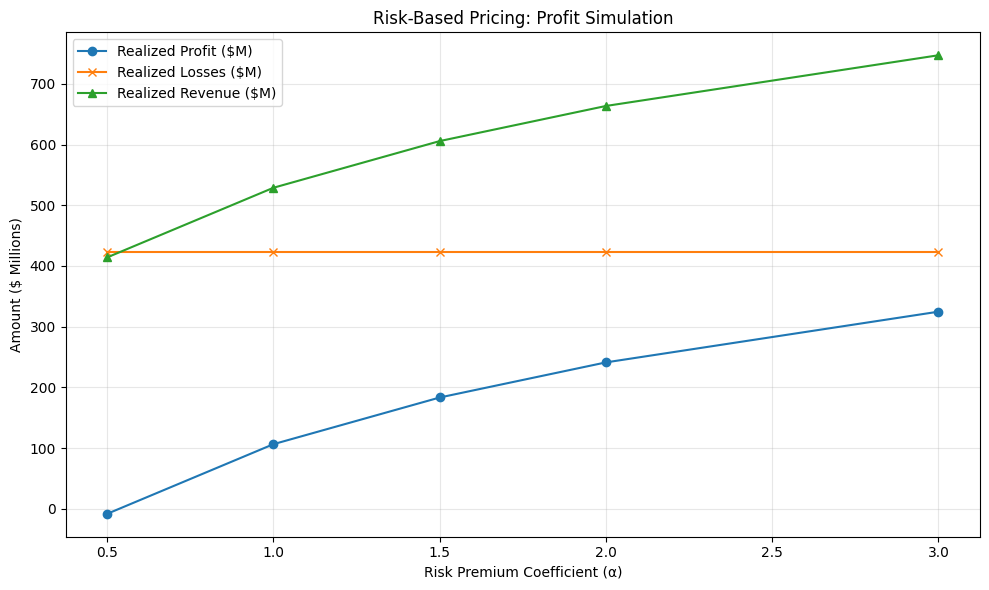

In [33]:
pricing_results = simulate_pricing_strategies(
    y_true=ytst["target"],
    y_pred_proba=y_pred_proba,
    loan_amount=test_df_unscaled["funded_amnt"],
    LGD=0.45,
    r0=r0/100,
    alpha_list=[0.5, 1.0, 1.5, 2.0, 3.0],
    max_rate = 0.36
)

---

### 📈 Profit Per Loan Formula

The expected profit for each loan *i* is:

$$
\text{Profit}_i = (1 - \text{PD}_i) \cdot r_i \cdot \text{EAD}_i - \text{PD}_i \cdot \text{LGD} \cdot \text{EAD}_i - C
$$

Where:
- **PD₍ᵢ₎** = Probability of default for loan *i*  
- **r₍ᵢ₎** = Interest rate charged for loan *i*  
- **EAD₍ᵢ₎** = Exposure at default (loan amount)  
- **LGD** = Loss given default (e.g. 0.45)  
- **C** = Fixed cost per loan (e.g. \$500)


In [34]:
def simulate_pricing_strategies(y_true, y_pred_proba, loan_amount, 
                                LGD=0.45, r0=r0, alpha_list=[0.5, 1.0, 1.5, 2.0, 3.0],
                                thresholds=np.linspace(0.1, 0.9, 17), cost_per_loan=500, max_rate = 0.36):
    results = []
    
    for alpha in alpha_list:
        for threshold in thresholds:
            # Approve only loans with PD below threshold
            mask = y_pred_proba < threshold
            if mask.sum() == 0:
                continue  # skip if no loans approved
            
            pd_approved = y_pred_proba[mask]
            y_true_approved = y_true[mask]
            ead_approved = loan_amount[mask]
            
            # Calculate interest rate for each loan
            raw = r0 + alpha * pd_approved
            r = np.minimum(raw, max_rate)
            # Profit formula
            profit = (
                (1 - pd_approved) * r * ead_approved  # expected interest income
                - pd_approved * LGD * ead_approved    # expected credit losses
                - cost_per_loan                       # fixed cost
            )
            
            portfolio_profit = profit.sum()
            approval_rate = mask.mean()
            avg_profit_per_loan = profit.mean()
            
            results.append({
                'alpha': alpha,
                'threshold': threshold,
                'portfolio_profit': portfolio_profit,
                'approval_rate': approval_rate,
                'avg_profit_per_loan': avg_profit_per_loan,
                'approved_loans': mask.sum()
            })
    
    results_df = pd.DataFrame(results)
    return results_df


In [35]:
results_df = simulate_pricing_strategies(
    y_true=ytst["target"],
    y_pred_proba=y_pred_proba,
    loan_amount=test_df_unscaled["funded_amnt"],
    LGD=0.45,
    r0=r0/100,
    alpha_list=[0.5, 1.0, 1.5, 2.0, 3.0],
    thresholds=np.linspace(0.1, 0.9, 17),
    cost_per_loan=500,
    max_rate = 0.36
)


In [36]:

results_df


,alpha,threshold,portfolio_profit,approval_rate,avg_profit_per_loan,approved_loans
0,0.5,0.10,3.461189e+07,0.462259,274.893879,125910
1,0.5,0.15,3.809250e+07,0.537264,260.301345,146340
2,0.5,0.20,3.908084e+07,0.582881,246.155289,158765
3,0.5,0.25,3.856322e+07,0.615075,230.181430,167534
4,0.5,0.30,3.697362e+07,0.638986,212.434715,174047
...,...,...,...,...,...,...
80,3.0,0.70,2.921757e+08,0.757266,1416.513427,206264
81,3.0,0.75,2.739633e+08,0.776709,1294.967569,211560
82,3.0,0.80,2.475718e+08,0.799556,1136.782105,217783
83,3.0,0.85,2.090462e+08,0.827737,927.202665,225459


## Risk-Based Pricing Simulation Results

This table presents simulated outcomes of a **risk-based loan pricing strategy** across combinations of:

- `alpha`: Risk premium multiplier in the interest rate formula  
- `threshold`: PD threshold for loan approval (only loans with PD < threshold are approved)

Each row in the table corresponds to one `(alpha, threshold)` pair.


### Parameter Definitions

##### - `alpha`
- Coefficient applied to predicted default probability (PD) in the interest rate formula:  
  **Interest Rate = r₀ + α × PD**
- Higher alpha = more risk-sensitive pricing

##### - `threshold`
- Maximum PD for loan approval.
- Loans with predicted default probability **below** this value are approved.

##### - `portfolio_profit`
- Total **expected profit** across all approved loans at the given `(alpha, threshold)` combination.

##### - `approval_rate`
- Proportion of the loan portfolio that is approved under the current threshold.

##### - `avg_profit_per_loan`
- Average expected profit per approved loan.

##### - `approved_loans`
- Total number of loans approved at this setting.

### Interpretation Guidelines

- **Lower thresholds** approve fewer but safer loans, increasing average profit per loan.
- **Higher thresholds** approve more loans, but include riskier ones, potentially reducing per-loan profitability.
- **Higher alpha** raises interest rates more sharply for risky borrowers, increasing revenue — but may hurt approval or overprice low-risk loans.
- The optimal pricing strategy lies in balancing `approval_rate` and `portfolio_profit` across these parameters.

Use this simulation grid to:
- Identify the **most profitable** (α, threshold) combination.
- Visualize **trade-offs** between profit, volume, and risk.
- Support **data-driven interest rate policy** in credit underwriting.

In [37]:
results_df.to_csv("normal_condition_simulation_pricing_strat.csv")

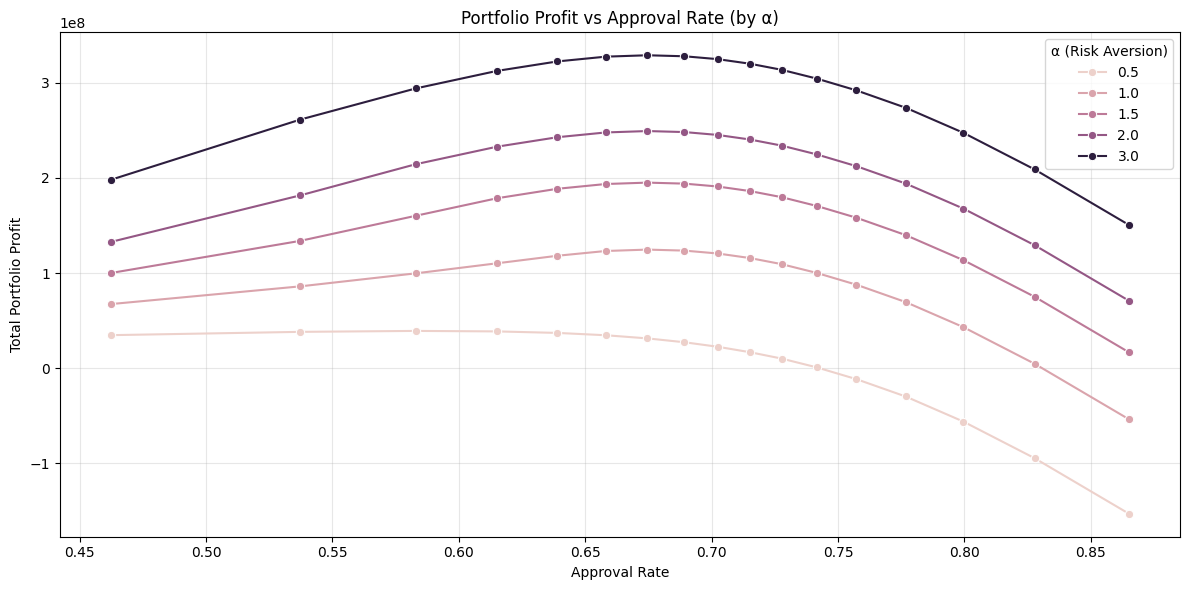

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.lineplot(data=results_df, x='approval_rate', y='portfolio_profit', hue='alpha', marker='o')
plt.title("Portfolio Profit vs Approval Rate (by α)")
plt.xlabel("Approval Rate")
plt.ylabel("Total Portfolio Profit")
plt.grid(True, alpha=0.3)
plt.legend(title='α (Risk Aversion)')
plt.tight_layout()
plt.show()

In [39]:
# Find row with maximum profit
max_profit_row = results_df.loc[results_df['portfolio_profit'].idxmax()]
print("🔹 Maximum Portfolio Profit")
max_profit_row

🔹 Maximum Portfolio Profit


alpha                  3.000000e+00
threshold              4.000000e-01
portfolio_profit       3.291285e+08
approval_rate          6.745686e-01
avg_profit_per_loan    1.791283e+03
approved_loans         1.837390e+05
Name: 74, dtype: float64

#### (Maximum Profit Setting)

- **Risk Premium Coefficient (α):** `3.0`  
- **Approval Threshold (PD):** `0.40`  
- **Total Expected Portfolio Profit:** `$329.1 Million`  
- **Approval Rate:** `67.46%`  
- **Average Profit per Approved Loan:** `$1,791.28`  
- **Number of Loans Approved:** `183,739`


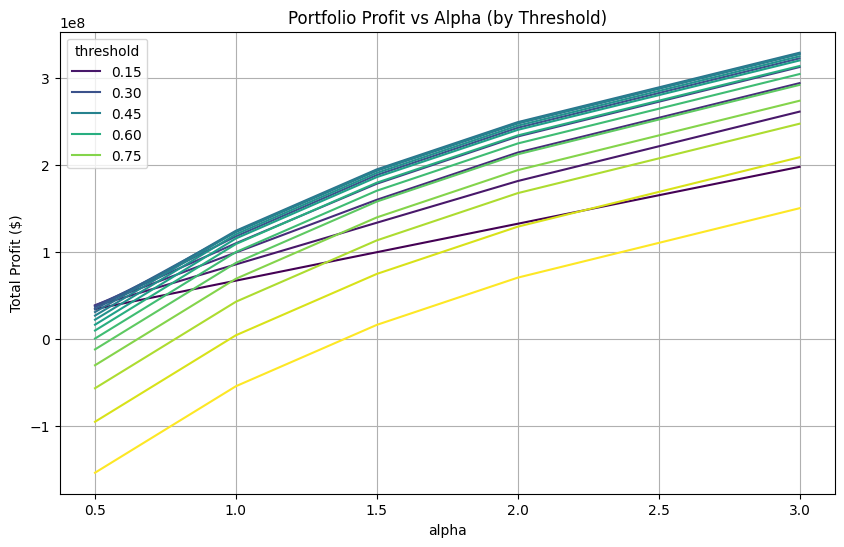

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df, x='alpha', y='portfolio_profit', hue='threshold', palette='viridis')
plt.title("Portfolio Profit vs Alpha (by Threshold)")
plt.ylabel("Total Profit ($)")
plt.grid(True)
plt.show()


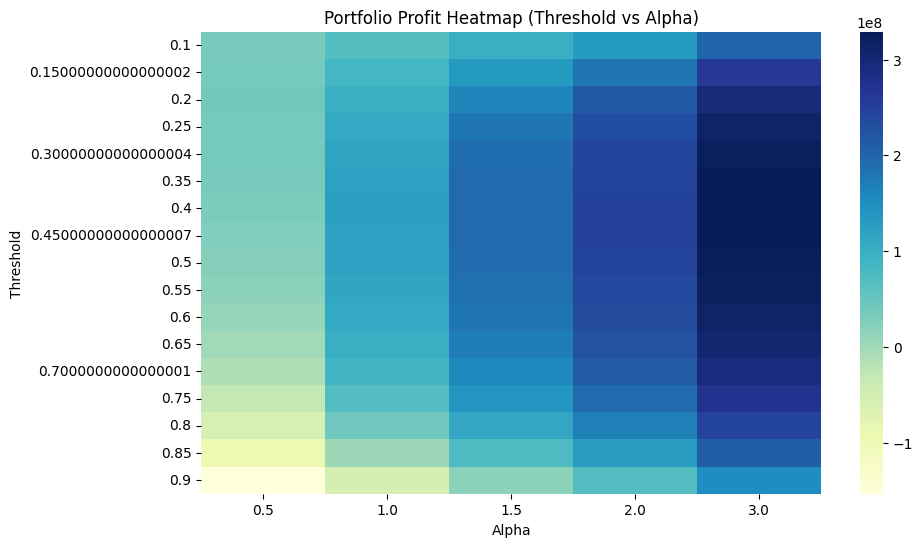

In [41]:
pivot = results_df.pivot(index='threshold', columns='alpha', values='portfolio_profit')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=False, cmap='YlGnBu', fmt='.0f')
plt.title("Portfolio Profit Heatmap (Threshold vs Alpha)")
plt.xlabel("Alpha")
plt.ylabel("Threshold")
plt.show()


---

### Strategy Optimization: Finding the "Sweet Spot"

This section explores alternative ways to **select the best pricing strategy**, not just based on raw profit, but considering a **balance between profit and approval rate**.



#### **Weighted Sweetness Score**

```python
w_profit = 0.6  # importance of avg profit per loan
w_approval = 0.4  # importance of approval rate
```

- Both `avg_profit_per_loan` and `approval_rate` are normalized to [0, 1] using `MinMaxScaler`.
- A **weighted average** (`sweetness`) is calculated:
  
  \[
  \text{sweetness} = w_{\text{profit}} \cdot \text{norm\_profit} + w_{\text{approval}} \cdot \text{norm\_approval}
  \]

- The strategy with the **highest sweetness score** is selected as the best balance between **profit per loan** and **volume** (approval rate).



#### **Sweetness Based on "Sharpe Ratio" Style Logic**

```python
results_df['sweetness_sharpe'] = avg_profit_per_loan / (1 + (1 - approval_rate))
```

- This mimics a **Sharpe-like ratio**:
  - It rewards high profit per loan.
  - Penalizes lower approval rates (by dividing by a function of unapproved fraction).
- The best row by this metric gives a **risk-adjusted profit efficiency**.



#### **Sweet Spot with Approval Rate Constraint**

```python
min_approval = 0.60
filtered = results_df[results_df['approval_rate'] >= min_approval]
sweet_spot_row = filtered.loc[filtered['avg_profit_per_loan'].idxmax()]
```

- This method sets a **minimum approval rate constraint** (e.g., 60%).
- Among strategies meeting that constraint, it picks the one with the **highest average profit per loan**.
- Useful for maintaining a **realistic loan volume** while still optimizing profit.



Have used these three methods to explore different notions of the “best” strategy depending on your business constraints and risk appetite.


In [42]:
# Adjustable weights
w_profit = 0.6  # weight for profit per loan
w_approval = 0.4  # weight for approval rate

# Normalize both columns to [0, 1]
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
normalized = scaler.fit_transform(results_df[['avg_profit_per_loan', 'approval_rate']])
results_df[['norm_profit', 'norm_approval']] = normalized

# Weighted score
results_df['sweetness'] = w_profit * results_df['norm_profit'] + w_approval * results_df['norm_approval']


In [43]:
best_row = results_df.loc[results_df['sweetness'].idxmax()]
print(best_row)

alpha                  3.000000e+00
threshold              5.000000e-01
portfolio_profit       3.250567e+08
approval_rate          7.023276e-01
avg_profit_per_loan    1.699198e+03
approved_loans         1.913000e+05
norm_profit            9.336200e-01
norm_approval          5.958847e-01
sweetness              7.985258e-01
Name: 76, dtype: float64


In [46]:
results_df

,alpha,threshold,portfolio_profit,approval_rate,avg_profit_per_loan,approved_loans,norm_profit,norm_approval,sweetness,sweetness_sharpe
0,0.5,0.10,3.461189e+07,0.462259,274.893879,125910,0.367755,0.000000,0.220653,178.764700
1,0.5,0.15,3.809250e+07,0.537264,260.301345,146340,0.361957,0.186174,0.291644,177.955124
2,0.5,0.20,3.908084e+07,0.582881,246.155289,158765,0.356337,0.299400,0.333562,173.701156
3,0.5,0.25,3.856322e+07,0.615075,230.181430,167534,0.349991,0.379310,0.361719,166.204922
4,0.5,0.30,3.697362e+07,0.638986,212.434715,174047,0.342940,0.438662,0.381229,156.085618
...,...,...,...,...,...,...,...,...,...,...
80,3.0,0.70,2.921757e+08,0.757266,1416.513427,206264,0.821311,0.732248,0.785686,1139.836002
81,3.0,0.75,2.739633e+08,0.776709,1294.967569,211560,0.773022,0.780510,0.776017,1058.593236
82,3.0,0.80,2.475718e+08,0.799556,1136.782105,217783,0.710176,0.837218,0.760993,946.967859
83,3.0,0.85,2.090462e+08,0.827737,927.202665,225459,0.626912,0.907168,0.739014,790.951052


In [45]:
results_df['sweetness_sharpe'] = results_df['avg_profit_per_loan'] / (1 + (1 - results_df['approval_rate']))

In [47]:
results_df.to_csv("normal_condition_simulation_pricing_strat_sharpeinc.csv")

In [48]:
best_row = results_df.loc[results_df['sweetness_sharpe'].idxmax()]
print(best_row)

alpha                  3.000000e+00
threshold              3.500000e-01
portfolio_profit       3.276567e+08
approval_rate          6.581100e-01
avg_profit_per_loan    1.827870e+03
approved_loans         1.792560e+05
norm_profit            9.847402e-01
norm_approval          4.861303e-01
sweetness              7.852963e-01
sweetness_sharpe       1.362161e+03
Name: 73, dtype: float64


### Best Strategy by Sharpe-Style Sweetness Score

The following strategy was selected based on the highest **Sharpe-style sweetness score**, which balances **average profit per loan** against **approval risk**:

| Metric                      | Value         |
|-----------------------------|---------------|
| **Alpha (Risk Premium)**    | 3.0           |
| **Approval Threshold (PD)** | 0.35          |
| **Portfolio Profit**        | \$327.7 million |
| **Approval Rate**           | 65.81%        |
| **Avg Profit per Loan**     | \$1,827.87    |
| **Approved Loans**          | 179,256       |
| **Sweetness (Sharpe)**      | 1,362.16      |

#### Interpretation:
- This strategy achieves **strong risk-adjusted profitability**, with a high average return per loan and decent approval volume.
- Though not the absolute top in profit or approval, it's the **most efficient per unit of approval risk**.
- Ideal when the objective is to **maximize per-loan return** while keeping scale at a **moderate but healthy level**.
- best to use this as the **default pricing policy** if you prioritize **profit quality over quantity**.


In [49]:
min_approval = 0.60
filtered = results_df[results_df['approval_rate'] >= min_approval]
sweet_spot_row = filtered.loc[filtered['avg_profit_per_loan'].idxmax()]
sweet_spot_row

alpha                  3.000000e+00
threshold              2.500000e-01
portfolio_profit       3.126653e+08
approval_rate          6.150745e-01
avg_profit_per_loan    1.866280e+03
approved_loans         1.675340e+05
norm_profit            1.000000e+00
norm_approval          3.793103e-01
sweetness              7.517241e-01
sweetness_sharpe       1.347567e+03
Name: 71, dtype: float64

### Best Strategy with Minimum 60% Approval Constraint

This strategy is the most profitable (on a per-loan basis) among all combinations that meet the **minimum approval rate of 60%**.

| Metric                      | Value           |
|-----------------------------|-----------------|
| **Alpha (Risk Premium)**    | 3.0             |
| **Approval Threshold (PD)** | 0.25            |
| **Portfolio Profit**        | \$312.7 million |
| **Approval Rate**           | 61.51%          |
| **Avg Profit per Loan**     | \$1,866.28      |
| **Approved Loans**          | 167,534         |
| **Sweetness Score**         | 0.752           |
| **Sharpe-style Score**      | 1,347.57        |

#### Interpretation:
- This strategy offers the **highest average profit per loan** among all that approve **at least 60%** of applicants.
- Approval volume is solid at **61.5%**, with over **167,000 loans** approved.
- A great choice for lenders aiming to **scale lending operations** while maintaining **strong per-loan profitability**.
- Ideal when needing a **balance between risk-based pricing and portfolio size**.


C:\Users\siddh\AppData\Local\Temp\ipykernel_30132\3691293355.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Strategy', y='Portfolio Profit ($B)', ax=axs[0], palette='crest')
C:\Users\siddh\AppData\Local\Temp\ipykernel_30132\3691293355.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Strategy', y='Approval Rate (%)', ax=axs[1], palette='flare')
C:\Users\siddh\AppData\Local\Temp\ipykernel_30132\3691293355.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Strategy

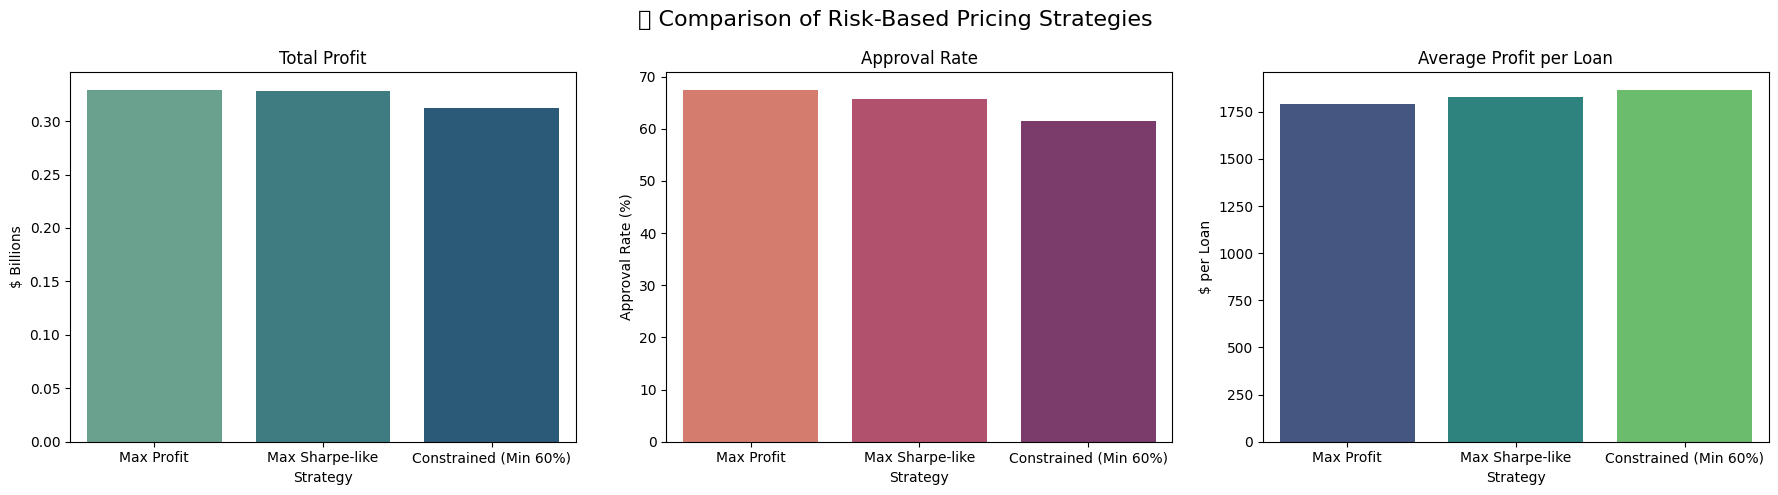

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify strategies
max_profit_row = results_df.loc[results_df['portfolio_profit'].idxmax()]
max_sharpe_row = results_df.loc[results_df['sweetness_sharpe'].idxmax()]
sweet_spot_row = results_df[results_df['approval_rate'] >= 0.60].loc[
    results_df[results_df['approval_rate'] >= 0.60]['avg_profit_per_loan'].idxmax()
]

# 2. Create comparison DataFrame
comparison_df = pd.DataFrame([
    {
        'Strategy': 'Max Profit',
        'Alpha': max_profit_row['alpha'],
        'Threshold': max_profit_row['threshold'],
        'Portfolio Profit ($B)': max_profit_row['portfolio_profit'] / 1e9,
        'Approval Rate (%)': max_profit_row['approval_rate'] * 100,
        'Profit per Loan': max_profit_row['avg_profit_per_loan']
    },
    {
        'Strategy': 'Max Sharpe-like',
        'Alpha': max_sharpe_row['alpha'],
        'Threshold': max_sharpe_row['threshold'],
        'Portfolio Profit ($B)': max_sharpe_row['portfolio_profit'] / 1e9,
        'Approval Rate (%)': max_sharpe_row['approval_rate'] * 100,
        'Profit per Loan': max_sharpe_row['avg_profit_per_loan']
    },
    {
        'Strategy': 'Constrained (Min 60%)',
        'Alpha': sweet_spot_row['alpha'],
        'Threshold': sweet_spot_row['threshold'],
        'Portfolio Profit ($B)': sweet_spot_row['portfolio_profit'] / 1e9,
        'Approval Rate (%)': sweet_spot_row['approval_rate'] * 100,
        'Profit per Loan': sweet_spot_row['avg_profit_per_loan']
    }
])

# 3. Barplot comparison
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=comparison_df, x='Strategy', y='Portfolio Profit ($B)', ax=axs[0], palette='crest')
axs[0].set_title('Total Profit')
axs[0].set_ylabel('$ Billions')

sns.barplot(data=comparison_df, x='Strategy', y='Approval Rate (%)', ax=axs[1], palette='flare')
axs[1].set_title('Approval Rate')

sns.barplot(data=comparison_df, x='Strategy', y='Profit per Loan', ax=axs[2], palette='viridis')
axs[2].set_title('Average Profit per Loan')
axs[2].set_ylabel('$ per Loan')

plt.suptitle('📊 Comparison of Risk-Based Pricing Strategies', fontsize=16)
plt.tight_layout()
plt.show()
